# MiniBatch KMeans

## Co je MiniBatch KMeans?

MiniBatch KMeans je varianta tradičního algoritmu K-means, která využívá mini-dávky (mini-batches) k redukci výpočetního času při zachování podobné kvality výsledků. Je to aproximační algoritmus, který v každé iteraci zpracovává pouze malý náhodný vzorek datové sady, namísto celého datasetu.

### Hlavní výhody oproti standardnímu K-means:
- **Výpočetní efektivita**: Výrazně rychlejší na velkých datových sadách
- **Paměťová efektivita**: Pracuje s menšími dávkami dat v paměti
- **Online učení**: Možnost aktualizovat model v průběhu času s novými daty

### Princip algoritmu:
1. Inicializace center shluků (stejně jako u K-means)
2. V každé iteraci:
   - Vybrat náhodnou mini-dávku bodů z datasetu
   - Přiřadit každý bod v mini-dávce k nejbližšímu centru
   - Aktualizovat centra shluků s použitím průměru přiřazených bodů
3. Opakovat proces pro stanovený počet iterací

### Kdy použít MiniBatch KMeans:
- Na velmi velkých datových sadách
- Když je rychlost důležitější než absolutní přesnost
- Když standardní K-means překračuje dostupnou paměť nebo je příliš pomalý

In [1]:
# Import potřebných knihoven
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.datasets import make_blobs, load_iris, fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Nastavení vizuálního stylu
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
np.random.seed(42)

## 1. Základní použití MiniBatch KMeans

Vytvoříme syntetická data a ukážeme si základní použití MiniBatch KMeans.

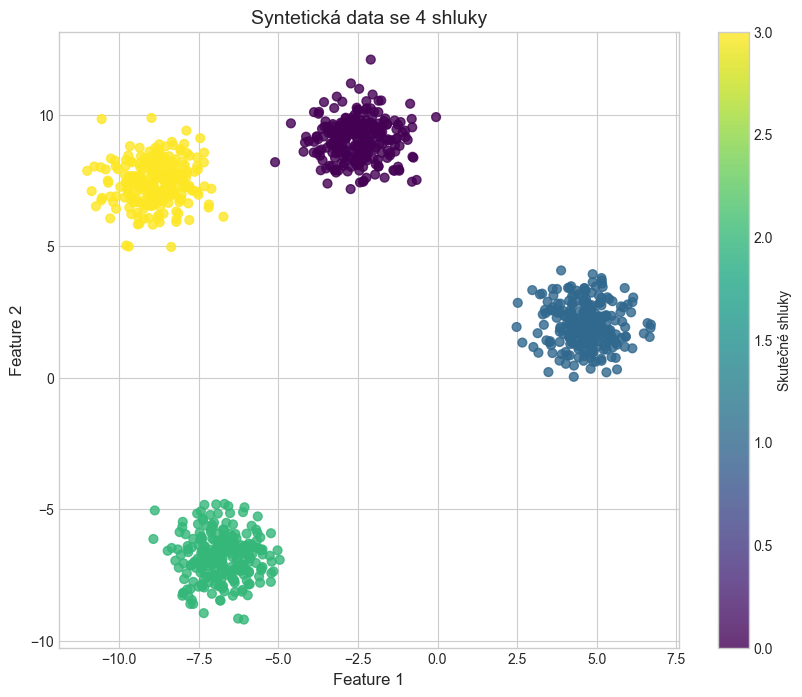

In [2]:
# Vytvoření syntetických dat s 4 shluky
n_samples = 1000
n_features = 2
n_clusters = 4
cluster_std = 0.8

X, y_true = make_blobs(n_samples=n_samples, 
                       n_features=n_features,
                       centers=n_clusters, 
                       cluster_std=cluster_std,
                       random_state=42)

# Vykreslení původních dat
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8, s=40)
plt.colorbar(label='Skutečné shluky')
plt.title('Syntetická data se 4 shluky', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True)
plt.show()

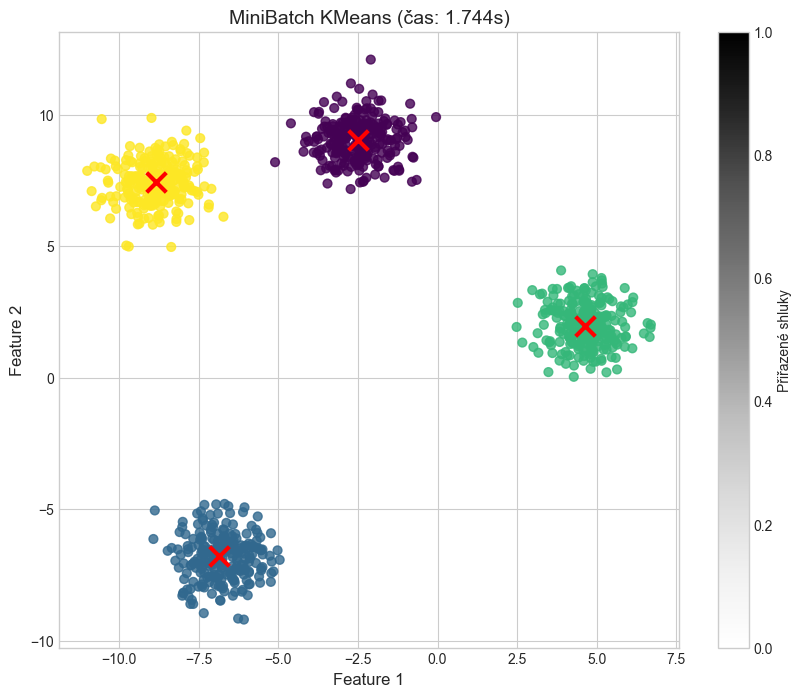

Doba výpočtu: 1.744 sekund
Silhouette skóre: 0.834 (vyšší je lepší, max=1)
Adjusted Rand Index: 1.000 (vyšší je lepší, max=1)
Inertia (suma čtverců vzdáleností bodů k nejbližším centrům): 1251.511 (nižší je lepší)


In [3]:
# Aplikace MiniBatch KMeans
mbk = MiniBatchKMeans(n_clusters=n_clusters, 
                     batch_size=100,  # Velikost mini-dávky
                     random_state=42,
                     max_iter=100)

# Měření času výpočtu
t0 = time.time()
mbk.fit(X)
t_mbk = time.time() - t0

# Získání přiřazení do shluků
mbk_labels = mbk.labels_

# Vykreslení výsledků
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=mbk_labels, cmap='viridis', alpha=0.8, s=40)
plt.scatter(mbk.cluster_centers_[:, 0], mbk.cluster_centers_[:, 1], 
           c='red', marker='x', s=200, linewidths=3)
plt.colorbar(label='Přiřazené shluky')
plt.title(f'MiniBatch KMeans (čas: {t_mbk:.3f}s)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True)
plt.show()

# Výpočet metrik kvality shlukování
silhouette = silhouette_score(X, mbk_labels)
ari = adjusted_rand_score(y_true, mbk_labels)
inertia = mbk.inertia_

print(f"Doba výpočtu: {t_mbk:.3f} sekund")
print(f"Silhouette skóre: {silhouette:.3f} (vyšší je lepší, max=1)")
print(f"Adjusted Rand Index: {ari:.3f} (vyšší je lepší, max=1)")
print(f"Inertia (suma čtverců vzdáleností bodů k nejbližším centrům): {inertia:.3f} (nižší je lepší)")

## 2. Porovnání MiniBatch KMeans a standardního KMeans

Porovnáme výkon a rychlost MiniBatch KMeans se standardním algoritmem KMeans.

Srovnání MiniBatch KMeans a standardního KMeans:


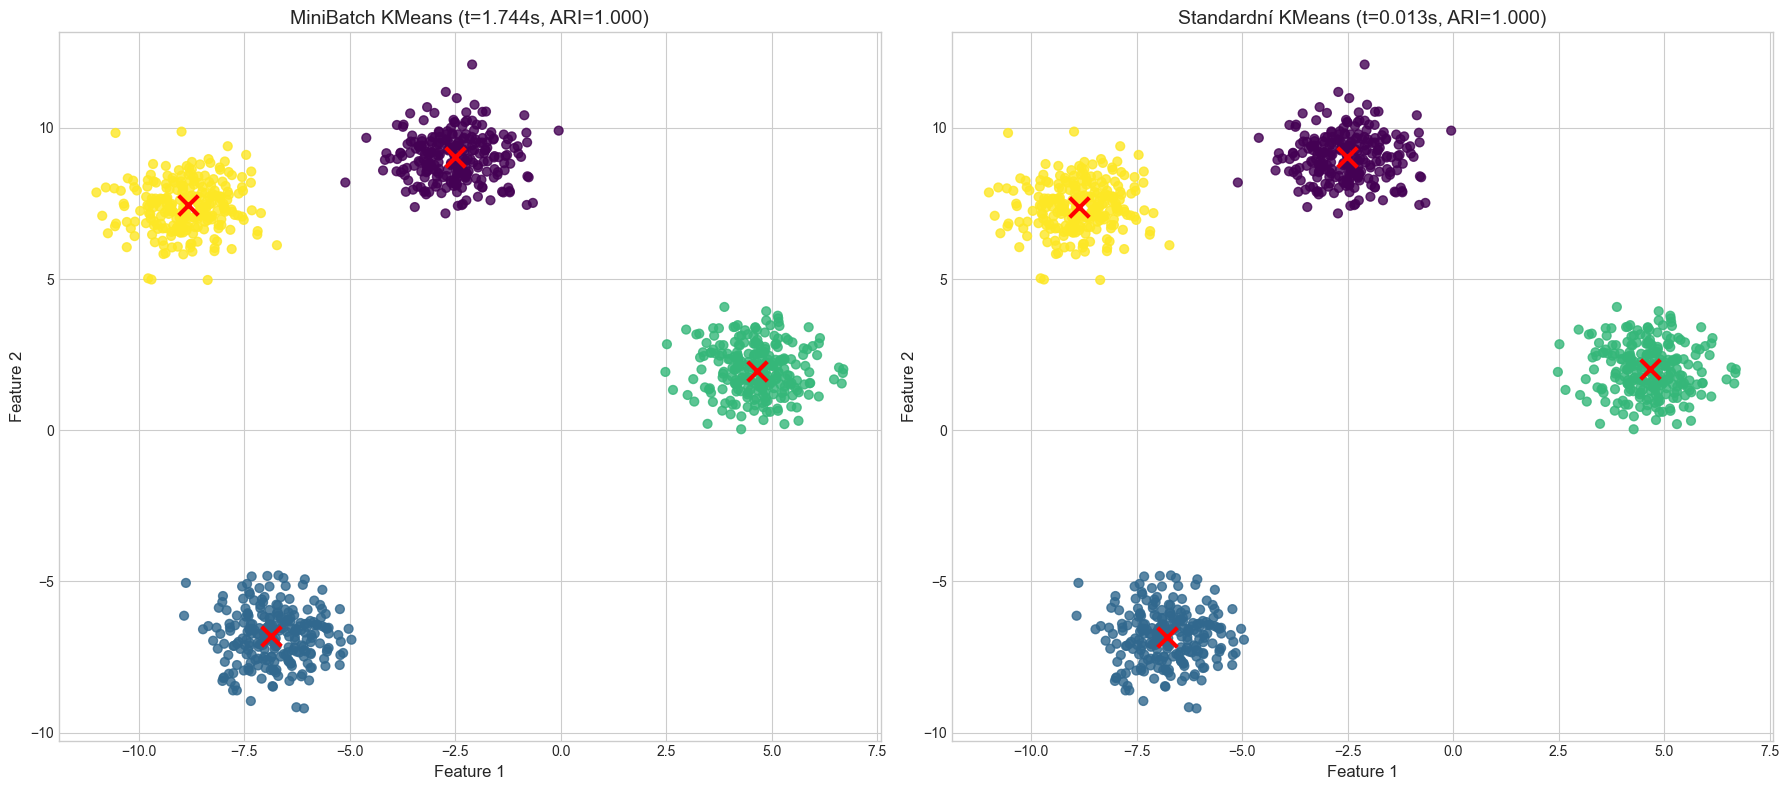

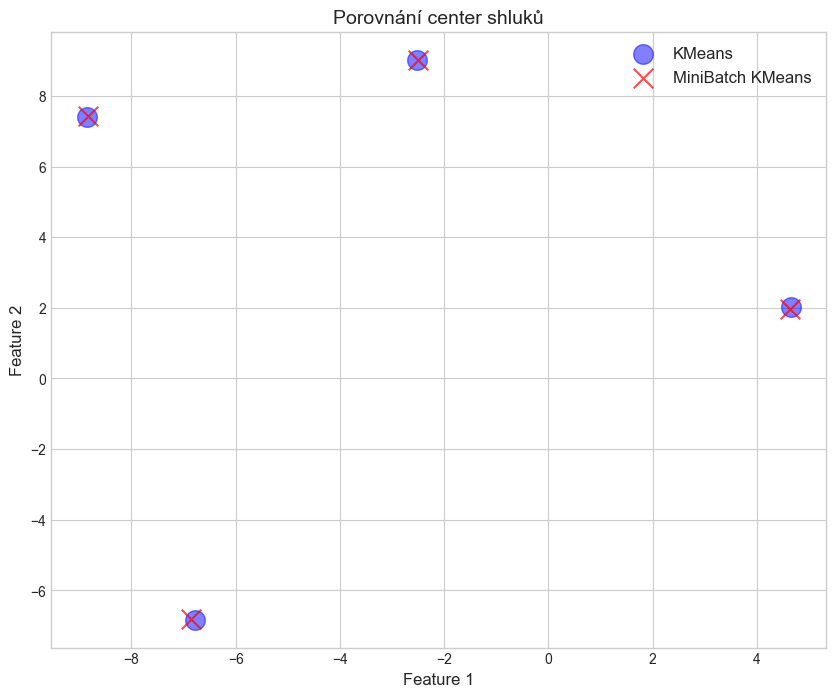

In [4]:
# Standardní KMeans
km = KMeans(n_clusters=n_clusters, random_state=42, max_iter=100)

# Měření času výpočtu
t0 = time.time()
km.fit(X)
t_km = time.time() - t0

# Získání přiřazení do shluků
km_labels = km.labels_

# Výpočet metrik kvality shlukování pro standardní KMeans
silhouette_km = silhouette_score(X, km_labels)
ari_km = adjusted_rand_score(y_true, km_labels)
inertia_km = km.inertia_

# Příprava dat pro srovnávací tabulku
comparison_data = {
    'Algoritmus': ['MiniBatch KMeans', 'Standardní KMeans'],
    'Doba výpočtu (s)': [t_mbk, t_km],
    'Silhouette skóre': [silhouette, silhouette_km],
    'Adjusted Rand Index': [ari, ari_km],
    'Inertia': [inertia, inertia_km]
}

# Vytvoření a zobrazení srovnávací tabulky
comparison_df = pd.DataFrame(comparison_data)
pd.set_option('display.precision', 3)  # Nastavení formátování na 3 desetinná místa
print("Srovnání MiniBatch KMeans a standardního KMeans:")
comparison_df

# Vizuální porovnání výsledků
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# MiniBatch KMeans
axes[0].scatter(X[:, 0], X[:, 1], c=mbk_labels, cmap='viridis', alpha=0.8, s=40)
axes[0].scatter(mbk.cluster_centers_[:, 0], mbk.cluster_centers_[:, 1], 
               c='red', marker='x', s=200, linewidths=3)
axes[0].set_title(f'MiniBatch KMeans (t={t_mbk:.3f}s, ARI={ari:.3f})', fontsize=14)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(True)

# Standardní KMeans
axes[1].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis', alpha=0.8, s=40)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], 
               c='red', marker='x', s=200, linewidths=3)
axes[1].set_title(f'Standardní KMeans (t={t_km:.3f}s, ARI={ari_km:.3f})', fontsize=14)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Porovnání center shluků mezi oběma algoritmy
plt.figure(figsize=(10, 8))
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], 
           c='blue', marker='o', s=200, alpha=0.5, label='KMeans')
plt.scatter(mbk.cluster_centers_[:, 0], mbk.cluster_centers_[:, 1], 
           c='red', marker='x', s=200, alpha=0.7, label='MiniBatch KMeans')
plt.title('Porovnání center shluků', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## 3. Vliv parametru batch_size na výkon MiniBatch KMeans

Provedeme analýzu vlivu velikosti mini-dávky (batch_size) na rychlost a kvalitu výsledků.

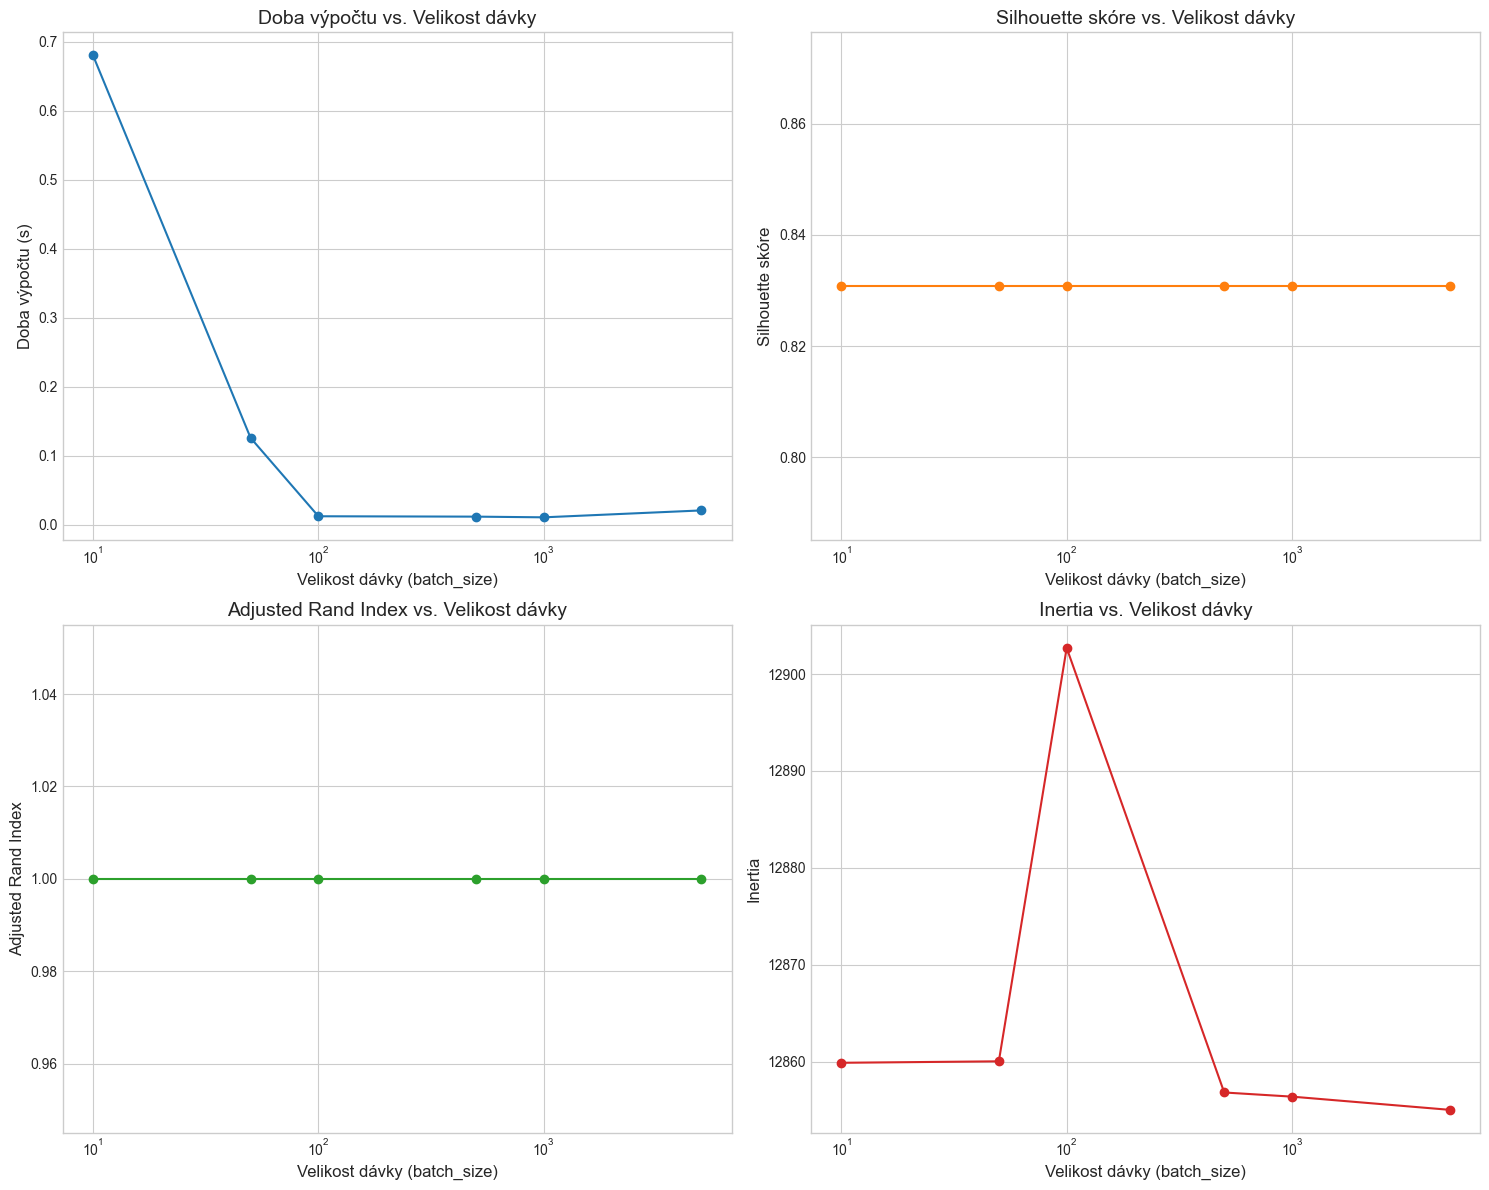

Vliv velikosti dávky na výkon MiniBatch KMeans:


,Velikost dávky,Doba výpočtu (s),Silhouette skóre,Adjusted Rand Index,Inertia
0,10,0.680,0.831,1.0,12859.878
1,50,0.126,0.831,1.0,12860.029
2,100,0.013,0.831,1.0,12902.695
3,500,0.012,0.831,1.0,12856.813
4,1000,0.011,0.831,1.0,12856.384
5,5000,0.021,0.831,1.0,12855.023


In [5]:
# Vytvoříme větší datovou sadu pro lepší demonstraci rozdílů
n_samples_large = 10000
X_large, y_large = make_blobs(n_samples=n_samples_large, 
                              n_features=2,
                              centers=n_clusters,
                              cluster_std=cluster_std,
                              random_state=42)

# Různé velikosti batch_size
batch_sizes = [10, 50, 100, 500, 1000, 5000]
times = []
silhouette_scores = []
ari_scores = []
inertia_values = []

for batch_size in batch_sizes:
    # Aplikace MiniBatch KMeans s danou velikostí dávky
    mbk = MiniBatchKMeans(n_clusters=n_clusters, 
                         batch_size=batch_size,
                         random_state=42,
                         max_iter=100)
    
    # Měření času výpočtu
    t0 = time.time()
    mbk.fit(X_large)
    t_batch = time.time() - t0
    
    # Výpočet metrik
    labels = mbk.labels_
    sil = silhouette_score(X_large, labels)
    ari_val = adjusted_rand_score(y_large, labels)
    inertia_val = mbk.inertia_
    
    # Uložení výsledků
    times.append(t_batch)
    silhouette_scores.append(sil)
    ari_scores.append(ari_val)
    inertia_values.append(inertia_val)

# Vizualizace výsledků
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Doba výpočtu vs. batch_size
axes[0, 0].plot(batch_sizes, times, 'o-', color='#1f77b4')
axes[0, 0].set_title('Doba výpočtu vs. Velikost dávky', fontsize=14)
axes[0, 0].set_xlabel('Velikost dávky (batch_size)', fontsize=12)
axes[0, 0].set_ylabel('Doba výpočtu (s)', fontsize=12)
axes[0, 0].grid(True)
axes[0, 0].set_xscale('log')

# Silhouette skóre vs. batch_size
axes[0, 1].plot(batch_sizes, silhouette_scores, 'o-', color='#ff7f0e')
axes[0, 1].set_title('Silhouette skóre vs. Velikost dávky', fontsize=14)
axes[0, 1].set_xlabel('Velikost dávky (batch_size)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette skóre', fontsize=12)
axes[0, 1].grid(True)
axes[0, 1].set_xscale('log')

# ARI vs. batch_size
axes[1, 0].plot(batch_sizes, ari_scores, 'o-', color='#2ca02c')
axes[1, 0].set_title('Adjusted Rand Index vs. Velikost dávky', fontsize=14)
axes[1, 0].set_xlabel('Velikost dávky (batch_size)', fontsize=12)
axes[1, 0].set_ylabel('Adjusted Rand Index', fontsize=12)
axes[1, 0].grid(True)
axes[1, 0].set_xscale('log')

# Inertia vs. batch_size
axes[1, 1].plot(batch_sizes, inertia_values, 'o-', color='#d62728')
axes[1, 1].set_title('Inertia vs. Velikost dávky', fontsize=14)
axes[1, 1].set_xlabel('Velikost dávky (batch_size)', fontsize=12)
axes[1, 1].set_ylabel('Inertia', fontsize=12)
axes[1, 1].grid(True)
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()

# Vytvoření DataFrame s výsledky
results_df = pd.DataFrame({
    'Velikost dávky': batch_sizes,
    'Doba výpočtu (s)': times,
    'Silhouette skóre': silhouette_scores,
    'Adjusted Rand Index': ari_scores,
    'Inertia': inertia_values
})

print("Vliv velikosti dávky na výkon MiniBatch KMeans:")
results_df

## 4. Hledání optimálního počtu shluků pomocí Elbow Method a Silhouette Score

Ukážeme si, jak určit optimální počet shluků pomocí metody lokte (Elbow method) a Silhouette skóre.

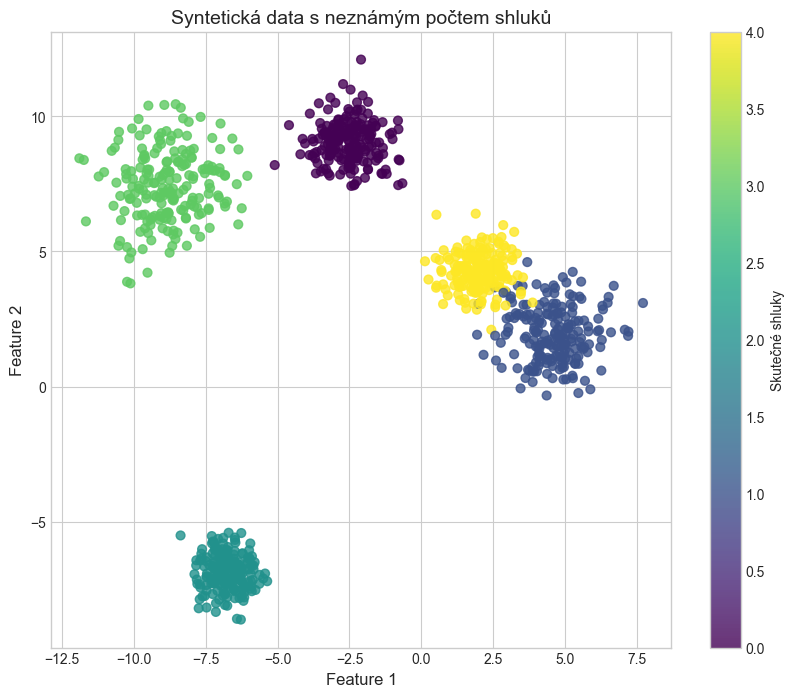

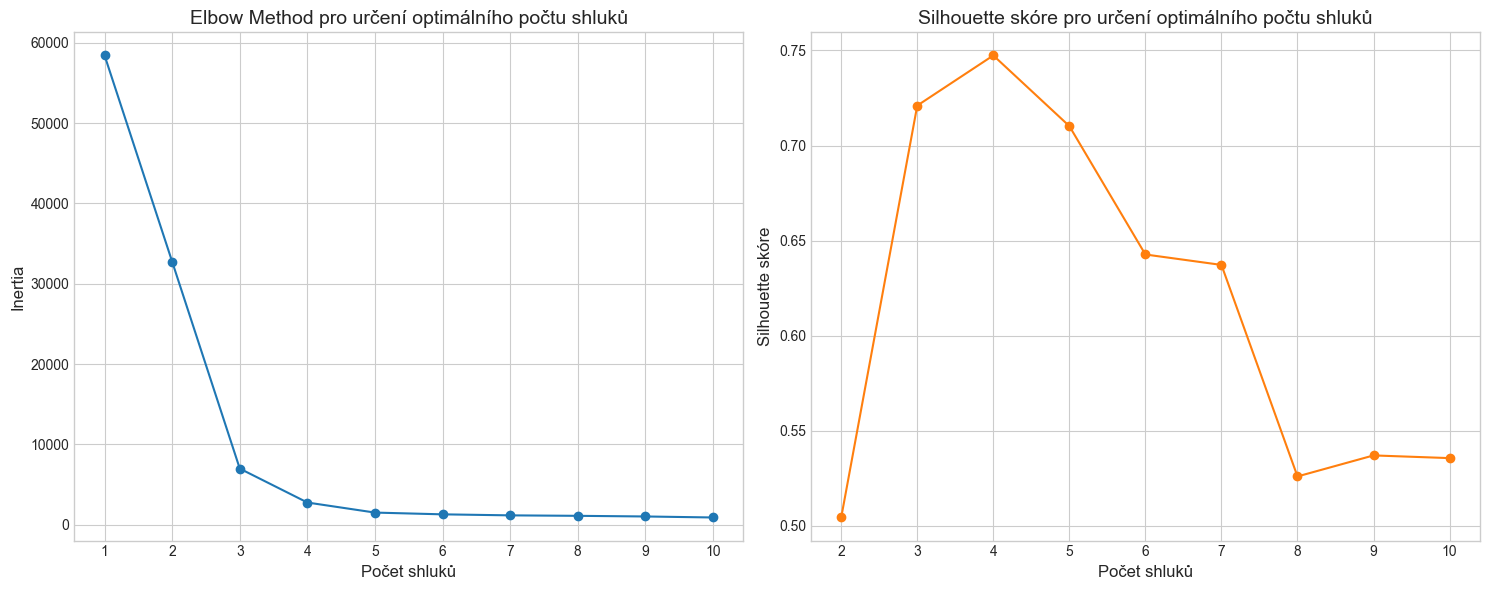

Optimální počet shluků podle Silhouette skóre: 4
Skutečný počet shluků v datech: 5


In [6]:
# Vytvoříme novou syntetickou datovou sadu s neznámým počtem shluků
X_unknown, y_unknown = make_blobs(n_samples=1000, 
                                 n_features=2,
                                 centers=5,  # Skutečný počet shluků je 5
                                 cluster_std=[0.8, 1.0, 0.6, 1.2, 0.7],
                                 random_state=42)

# Vykreslení původních dat
plt.figure(figsize=(10, 8))
plt.scatter(X_unknown[:, 0], X_unknown[:, 1], c=y_unknown, cmap='viridis', alpha=0.8, s=40)
plt.colorbar(label='Skutečné shluky')
plt.title('Syntetická data s neznámým počtem shluků', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True)
plt.show()

# Testování různých počtů shluků
n_clusters_range = range(1, 11)  # Testujeme 1 až 10 shluků
inertias = []
silhouette_scores = []
times = []

for n in n_clusters_range:
    if n == 1:
        # Pro 1 shluk silhouette score nelze vypočítat
        mbk = MiniBatchKMeans(n_clusters=n, batch_size=100, random_state=42)
        t0 = time.time()
        mbk.fit(X_unknown)
        t_fit = time.time() - t0
        inertias.append(mbk.inertia_)
        silhouette_scores.append(None)  # Nelze vypočítat pro 1 shluk
        times.append(t_fit)
    else:
        mbk = MiniBatchKMeans(n_clusters=n, batch_size=100, random_state=42)
        t0 = time.time()
        labels = mbk.fit_predict(X_unknown)
        t_fit = time.time() - t0
        inertias.append(mbk.inertia_)
        silhouette_scores.append(silhouette_score(X_unknown, labels))
        times.append(t_fit)

# Vykreslení Elbow Method (metody lokte)
plt.figure(figsize=(15, 6))

plt.subplot(121)
plt.plot(n_clusters_range, inertias, 'o-', color='#1f77b4')
plt.title('Elbow Method pro určení optimálního počtu shluků', fontsize=14)
plt.xlabel('Počet shluků', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(n_clusters_range)
plt.grid(True)

plt.subplot(122)
plt.plot(list(n_clusters_range)[1:], silhouette_scores[1:], 'o-', color='#ff7f0e')
plt.title('Silhouette skóre pro určení optimálního počtu shluků', fontsize=14)
plt.xlabel('Počet shluků', fontsize=12)
plt.ylabel('Silhouette skóre', fontsize=12)
plt.xticks(list(n_clusters_range)[1:])
plt.grid(True)

plt.tight_layout()
plt.show()

# Určení optimálního počtu shluků podle Silhouette skóre
optimal_n_silhouette = np.argmax(silhouette_scores[1:]) + 2  # +1 pro index a +1 protože začínáme od 2
print(f"Optimální počet shluků podle Silhouette skóre: {optimal_n_silhouette}")
print(f"Skutečný počet shluků v datech: 5")

## 5. MiniBatchKMeans na reálných datech

Aplikujeme MiniBatchKMeans na reálná data - konkrétně dataset Iris.

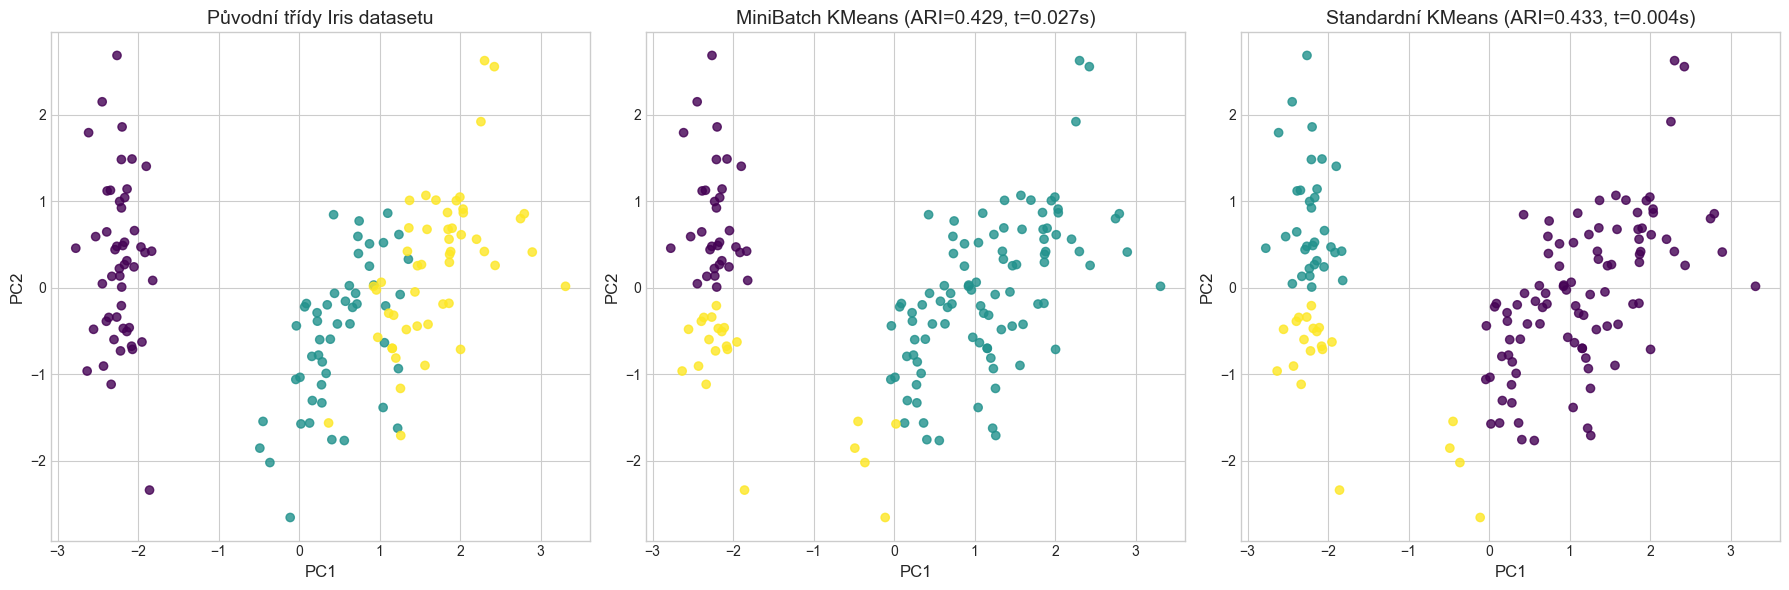

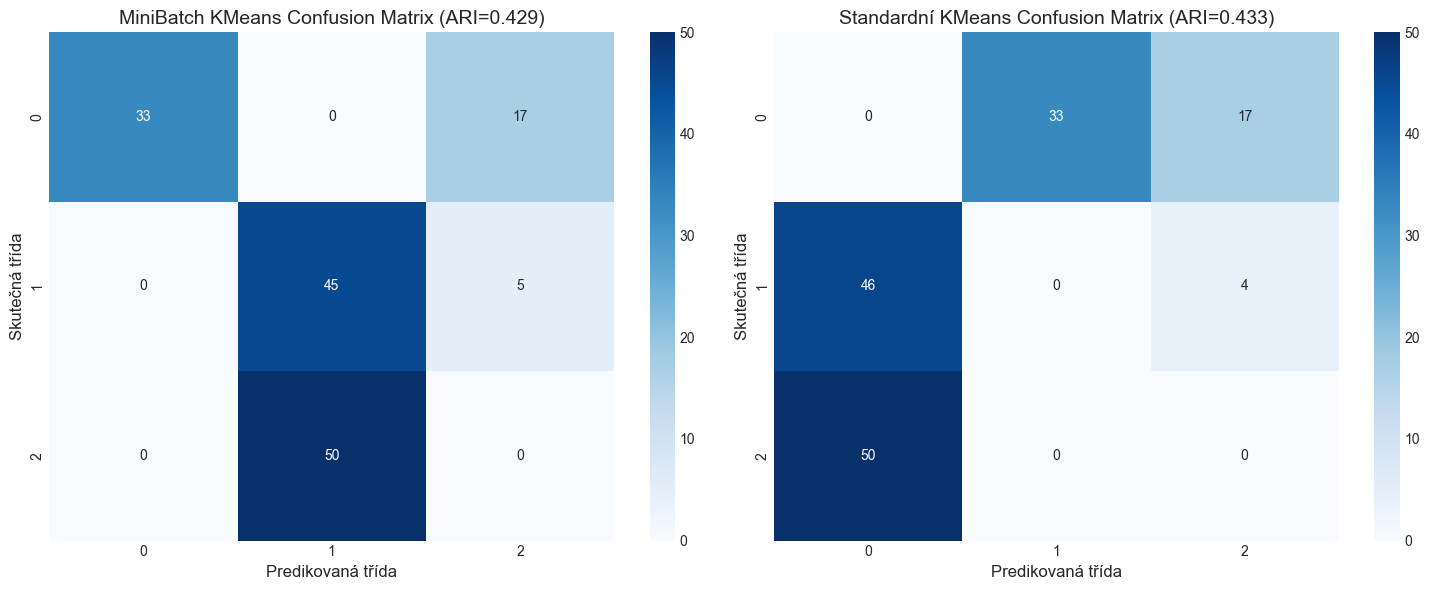

In [7]:
# Načtení Iris datasetu
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardizace příznaků
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Aplikace MiniBatch KMeans s optimálním počtem shluků (známe, že Iris má 3 druhy)
mbk_iris = MiniBatchKMeans(n_clusters=3, batch_size=50, random_state=42)

# Měření času výpočtu
t0 = time.time()
mbk_iris_labels = mbk_iris.fit_predict(X_iris_scaled)
t_mbk_iris = time.time() - t0

# Pro srovnání použijeme standardní KMeans
km_iris = KMeans(n_clusters=3, random_state=42)
t0 = time.time()
km_iris_labels = km_iris.fit_predict(X_iris_scaled)
t_km_iris = time.time() - t0

# Výpočet metrik kvality
mbk_silhouette = silhouette_score(X_iris_scaled, mbk_iris_labels)
mbk_ari = adjusted_rand_score(y_iris, mbk_iris_labels)
km_silhouette = silhouette_score(X_iris_scaled, km_iris_labels)
km_ari = adjusted_rand_score(y_iris, km_iris_labels)

# Vizualizace výsledků pomocí PCA
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Původní třídy
axes[0].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris, cmap='viridis', alpha=0.8)
axes[0].set_title('Původní třídy Iris datasetu', fontsize=14)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].grid(True)

# MiniBatch KMeans shluky
axes[1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=mbk_iris_labels, cmap='viridis', alpha=0.8)
axes[1].set_title(f'MiniBatch KMeans (ARI={mbk_ari:.3f}, t={t_mbk_iris:.3f}s)', fontsize=14)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].grid(True)

# Standardní KMeans shluky
axes[2].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=km_iris_labels, cmap='viridis', alpha=0.8)
axes[2].set_title(f'Standardní KMeans (ARI={km_ari:.3f}, t={t_km_iris:.3f}s)', fontsize=14)
axes[2].set_xlabel('PC1', fontsize=12)
axes[2].set_ylabel('PC2', fontsize=12)
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Zobrazení confusion matrix pro lepší interpretaci výsledků
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        plt.figure(figsize=(8, 6))
        ax = plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Predikovaná třída', fontsize=12)
    ax.set_ylabel('Skutečná třída', fontsize=12)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_confusion_matrix(y_iris, mbk_iris_labels, 
                     title=f'MiniBatch KMeans Confusion Matrix (ARI={mbk_ari:.3f})',
                     ax=axes[0])

plot_confusion_matrix(y_iris, km_iris_labels, 
                     title=f'Standardní KMeans Confusion Matrix (ARI={km_ari:.3f})',
                     ax=axes[1])

plt.tight_layout()
plt.show()

## 6. Škálování na větší datové sady

Porovnáme výkon MiniBatch KMeans a standardního KMeans na větších datových sadách.

Zpracování datové sady velikosti 1000...
Zpracování datové sady velikosti 5000...
Zpracování datové sady velikosti 10000...
Zpracování datové sady velikosti 50000...
Zpracování datové sady velikosti 100000...
Odhad času pro standardní KMeans: 0.14s (příliš velká datová sada)
Velikost 1000: Poměr inertia KMeans/MiniBatchKMeans = 0.999
Velikost 5000: Poměr inertia KMeans/MiniBatchKMeans = 1.000
Velikost 10000: Poměr inertia KMeans/MiniBatchKMeans = 1.000
Velikost 50000: Poměr inertia KMeans/MiniBatchKMeans = 1.000
Velikost 100000: Poměr inertia KMeans/MiniBatchKMeans = 0.500


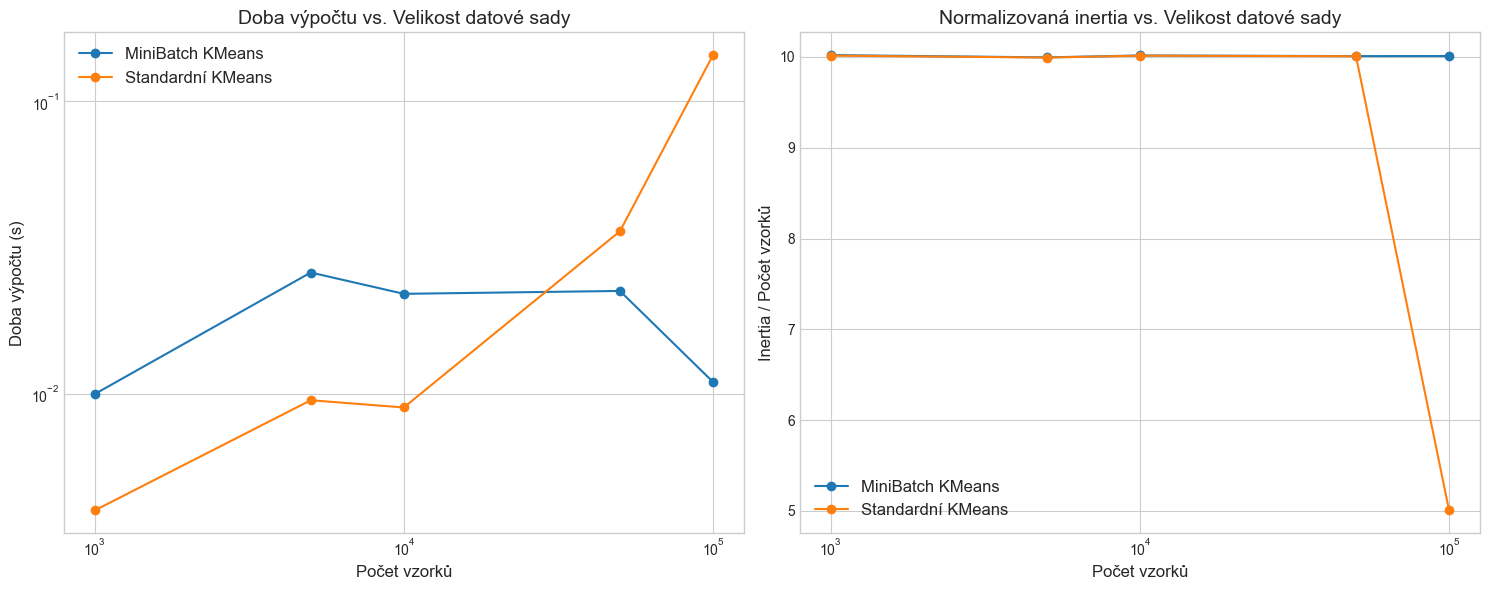

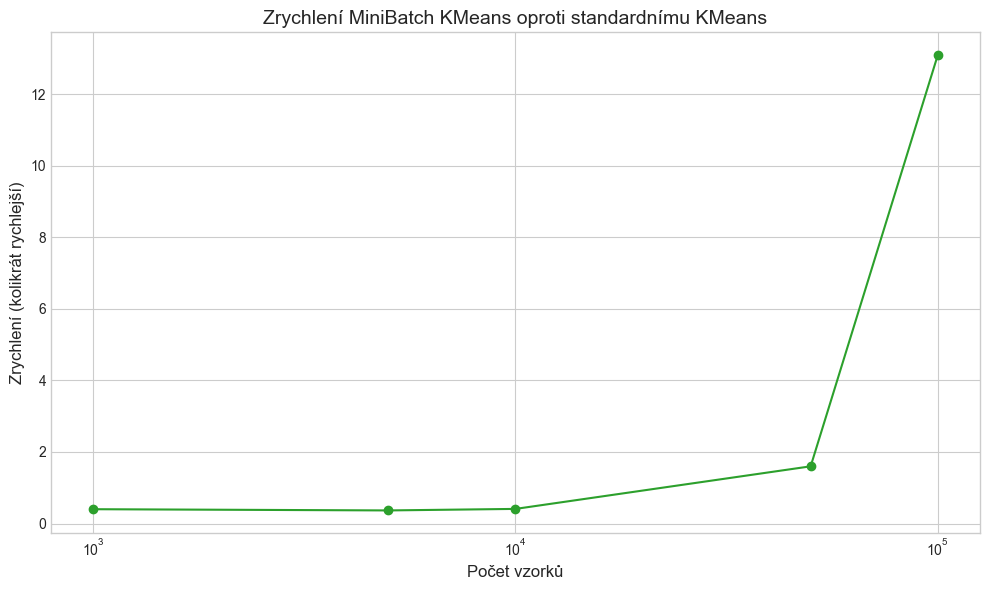

In [8]:
# Vytvoření větších datových sad různých velikostí
n_features = 10  # Zvýšíme počet dimenzí pro lepší demonstraci rozdílů
sizes = [1000, 5000, 10000, 50000, 100000]
mbk_times = []
km_times = []
mbk_inertias = []
km_inertias = []

for size in sizes:
    print(f"Zpracování datové sady velikosti {size}...")
    
    # Vytvoření datové sady
    X_large, y_large = make_blobs(n_samples=size, 
                                 n_features=n_features,
                                 centers=5,
                                 random_state=42)
    
    # MiniBatch KMeans
    mbk = MiniBatchKMeans(n_clusters=5, batch_size=500, random_state=42)
    t0 = time.time()
    mbk.fit(X_large)
    t_mbk = time.time() - t0
    mbk_times.append(t_mbk)
    mbk_inertias.append(mbk.inertia_)
    
    # Standardní KMeans - pro větší datové sady může být pomalý
    if size <= 50000:  # Omezíme standardní KMeans pro velmi velké datasety
        km = KMeans(n_clusters=5, random_state=42)
        t0 = time.time()
        km.fit(X_large)
        t_km = time.time() - t0
        km_times.append(t_km)
        km_inertias.append(km.inertia_)
    else:
        # Pro velmi velké datové sady pouze odhadneme čas
        # Předpokládáme lineární škálování pro inertia a kvadratické pro čas
        if len(km_times) > 0:
            last_time = km_times[-1]
            last_size = sizes[len(km_times) - 1]
            estimated_time = last_time * (size / last_size) ** 2  # Kvadratické škálování
            km_times.append(estimated_time)
            # Pro inertia použijeme poslední hodnotu (aproximace)
            km_inertias.append(km_inertias[-1])
            print(f"Odhad času pro standardní KMeans: {estimated_time:.2f}s (příliš velká datová sada)")

# Vizualizace výsledků
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Porovnání časů výpočtu
axes[0].plot(sizes[:len(mbk_times)], mbk_times, 'o-', color='#1f77b4', label='MiniBatch KMeans')
axes[0].plot(sizes[:len(km_times)], km_times, 'o-', color='#ff7f0e', label='Standardní KMeans')
axes[0].set_title('Doba výpočtu vs. Velikost datové sady', fontsize=14)
axes[0].set_xlabel('Počet vzorků', fontsize=12)
axes[0].set_ylabel('Doba výpočtu (s)', fontsize=12)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True)
axes[0].legend(fontsize=12)

# Porovnání inertia
for i in range(min(len(mbk_inertias), len(km_inertias))):
    ratio = km_inertias[i] / mbk_inertias[i] if mbk_inertias[i] > 0 else 1
    print(f"Velikost {sizes[i]}: Poměr inertia KMeans/MiniBatchKMeans = {ratio:.3f}")

# Normalizace inertia pro lepší porovnání
norm_mbk_inertias = [val / size for val, size in zip(mbk_inertias, sizes[:len(mbk_inertias)])]
norm_km_inertias = [val / size for val, size in zip(km_inertias, sizes[:len(km_inertias)])]

axes[1].plot(sizes[:len(mbk_inertias)], norm_mbk_inertias, 'o-', color='#1f77b4', label='MiniBatch KMeans')
axes[1].plot(sizes[:len(km_inertias)], norm_km_inertias, 'o-', color='#ff7f0e', label='Standardní KMeans')
axes[1].set_title('Normalizovaná inertia vs. Velikost datové sady', fontsize=14)
axes[1].set_xlabel('Počet vzorků', fontsize=12)
axes[1].set_ylabel('Inertia / Počet vzorků', fontsize=12)
axes[1].set_xscale('log')
axes[1].grid(True)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

# Zrychlení MiniBatch KMeans oproti standardnímu KMeans
speedup = [km / mbk for km, mbk in zip(km_times, mbk_times[:len(km_times)])]
plt.figure(figsize=(10, 6))
plt.plot(sizes[:len(speedup)], speedup, 'o-', color='#2ca02c')
plt.title('Zrychlení MiniBatch KMeans oproti standardnímu KMeans', fontsize=14)
plt.xlabel('Počet vzorků', fontsize=12)
plt.ylabel('Zrychlení (kolikrát rychlejší)', fontsize=12)
plt.xscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Aplikace na obrazová data

Ukážeme si aplikaci MiniBatch KMeans na obrazová data - konkrétně na dataset obličejů Olivetti.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\pavel\scikit_learn_data
Dataset obsahuje 400 obrázků, každý s 4096 příznaky.
Celkem je v datasetu 40 různých osob.


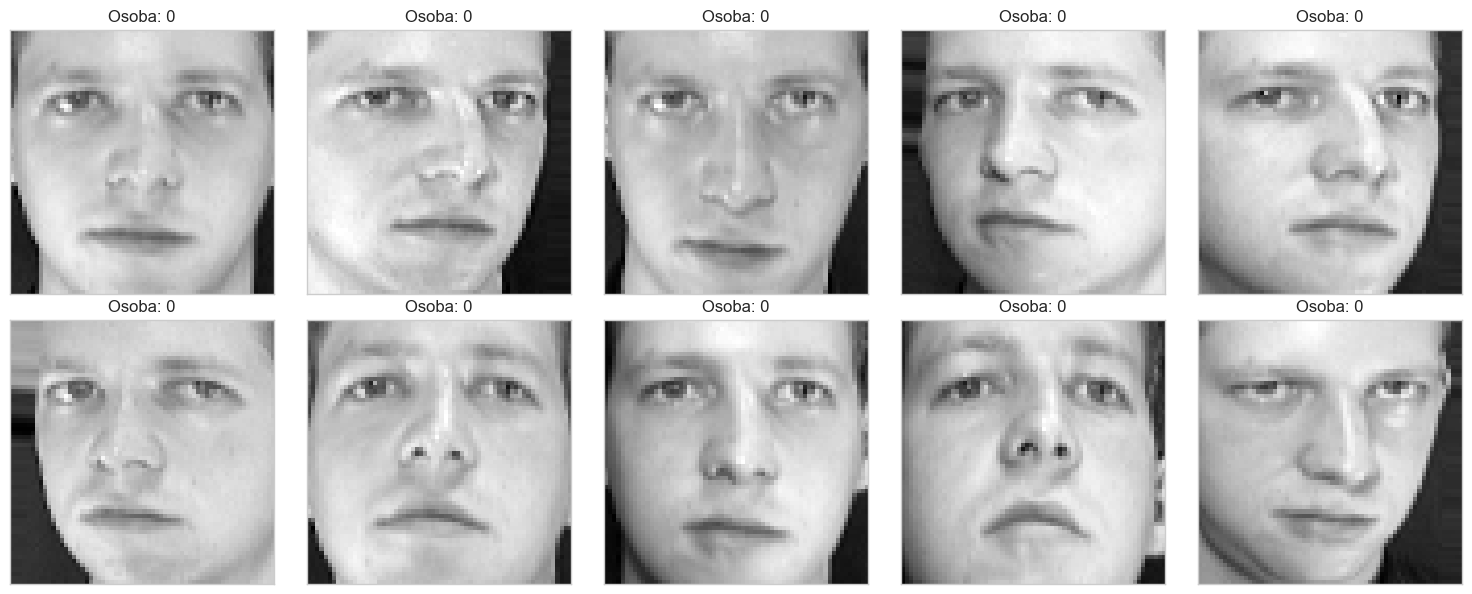

Redukce dimenzionality z 4096 na 50 příznaků.
Podíl zachované variance: 0.87
MiniBatch KMeans shlukování dokončeno za 0.031s
Standardní KMeans shlukování dokončeno za 0.008s
MiniBatch KMeans Silhouette skóre: -0.005
Standardní KMeans Silhouette skóre: 0.081


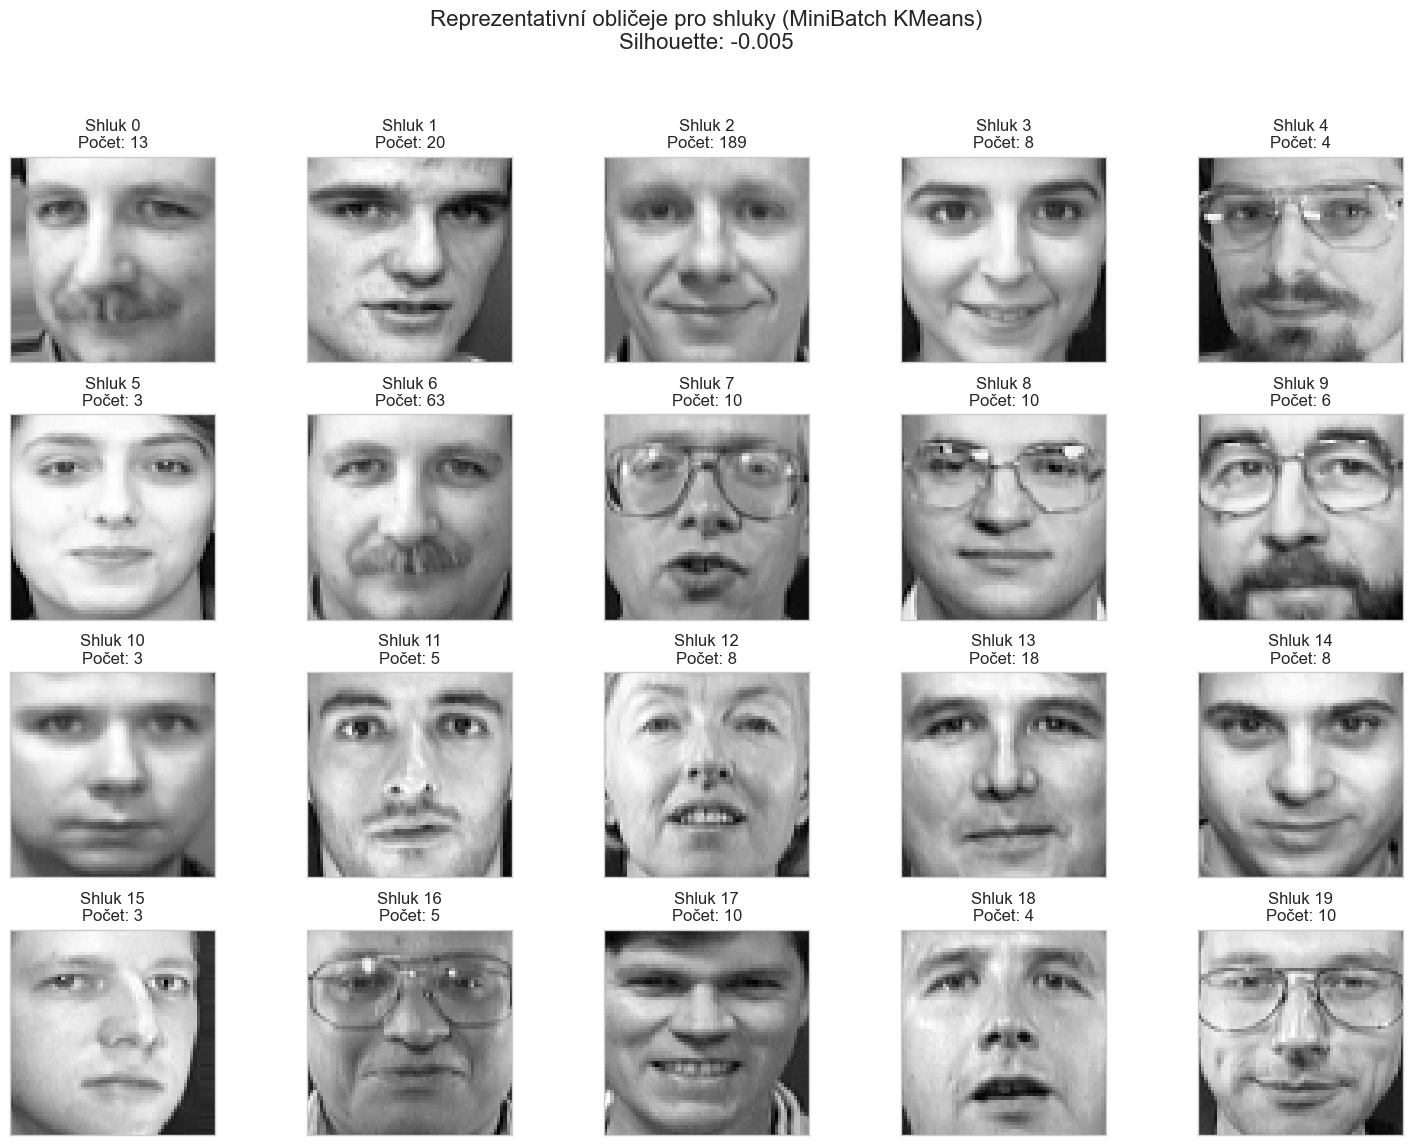

In [9]:
# Načtení datasetu Olivetti faces
faces = fetch_olivetti_faces()
X_faces = faces.data
y_faces = faces.target

# Informace o datasetu
n_samples, n_features = X_faces.shape
n_classes = len(np.unique(y_faces))
image_shape = (64, 64)

print(f"Dataset obsahuje {n_samples} obrázků, každý s {n_features} příznaky.")
print(f"Celkem je v datasetu {n_classes} různých osob.")

# Zobrazení několika obrázků
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_faces[i].reshape(image_shape), cmap='gray')
    axes[i].set_title(f"Osoba: {y_faces[i]}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

# Aplikace PCA pro redukci dimenzionality
n_components = 50  # Počet hlavních komponent, které zachováme
pca = PCA(n_components=n_components, whiten=True, random_state=42).fit(X_faces)
X_faces_pca = pca.transform(X_faces)

print(f"Redukce dimenzionality z {n_features} na {n_components} příznaků.")
print(f"Podíl zachované variance: {pca.explained_variance_ratio_.sum():.2f}")

# Aplikace MiniBatch KMeans pro shlukování obličejů
# Nastavíme počet shluků na menší hodnotu než je počet osob, abychom viděli, jak algoritmus seskupuje podobné obličeje
n_clusters = 20  # Méně než počet osob v datasetu (40)

mbk_faces = MiniBatchKMeans(n_clusters=n_clusters, batch_size=50, random_state=42)
t0 = time.time()
mbk_faces_labels = mbk_faces.fit_predict(X_faces_pca)
t_mbk_faces = time.time() - t0

print(f"MiniBatch KMeans shlukování dokončeno za {t_mbk_faces:.3f}s")

# Standardní KMeans pro srovnání
km_faces = KMeans(n_clusters=n_clusters, random_state=42)
t0 = time.time()
km_faces_labels = km_faces.fit_predict(X_faces_pca)
t_km_faces = time.time() - t0

print(f"Standardní KMeans shlukování dokončeno za {t_km_faces:.3f}s")

# Metriky výkonu
mbk_silhouette = silhouette_score(X_faces_pca, mbk_faces_labels)
km_silhouette = silhouette_score(X_faces_pca, km_faces_labels)

print(f"MiniBatch KMeans Silhouette skóre: {mbk_silhouette:.3f}")
print(f"Standardní KMeans Silhouette skóre: {km_silhouette:.3f}")

# Vizualizace zástupců jednotlivých shluků z MiniBatch KMeans
def plot_cluster_representatives(X, labels, centers, n_clusters, image_shape, title):
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()
    
    for i in range(min(n_clusters, 20)):  # Zobrazíme max. 20 shluků
        # Najdeme obrázek nejblíže centru shluku
        cluster_samples = X_faces_pca[labels == i]
        if len(cluster_samples) > 0:
            # Najdeme index obrázku nejblíže centru
            center = centers[i]
            distances = np.linalg.norm(cluster_samples - center, axis=1)
            closest_idx = np.argmin(distances)
            
            # Najdeme původní index obrázku
            original_indices = np.where(labels == i)[0]
            closest_original_idx = original_indices[closest_idx]
            
            # Zobrazíme obrázek
            axes[i].imshow(X[closest_original_idx].reshape(image_shape), cmap='gray')
            axes[i].set_title(f"Shluk {i}\nPočet: {len(cluster_samples)}")
            axes[i].set_xticks([])
            axes[i].set_yticks([])
    
    # Odstraníme prázdné osy
    for i in range(n_clusters, len(axes)):
        fig.delaxes(axes[i])
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Zobrazení zástupců shluků
plot_cluster_representatives(X_faces, mbk_faces_labels, mbk_faces.cluster_centers_, n_clusters, image_shape, 
                           f"Reprezentativní obličeje pro shluky (MiniBatch KMeans)\nSilhouette: {mbk_silhouette:.3f}")

## 8. Online učení s MiniBatch KMeans

Ukážeme si, jak lze použít MiniBatch KMeans pro online učení, kde model postupně zpracovává nové dávky dat.

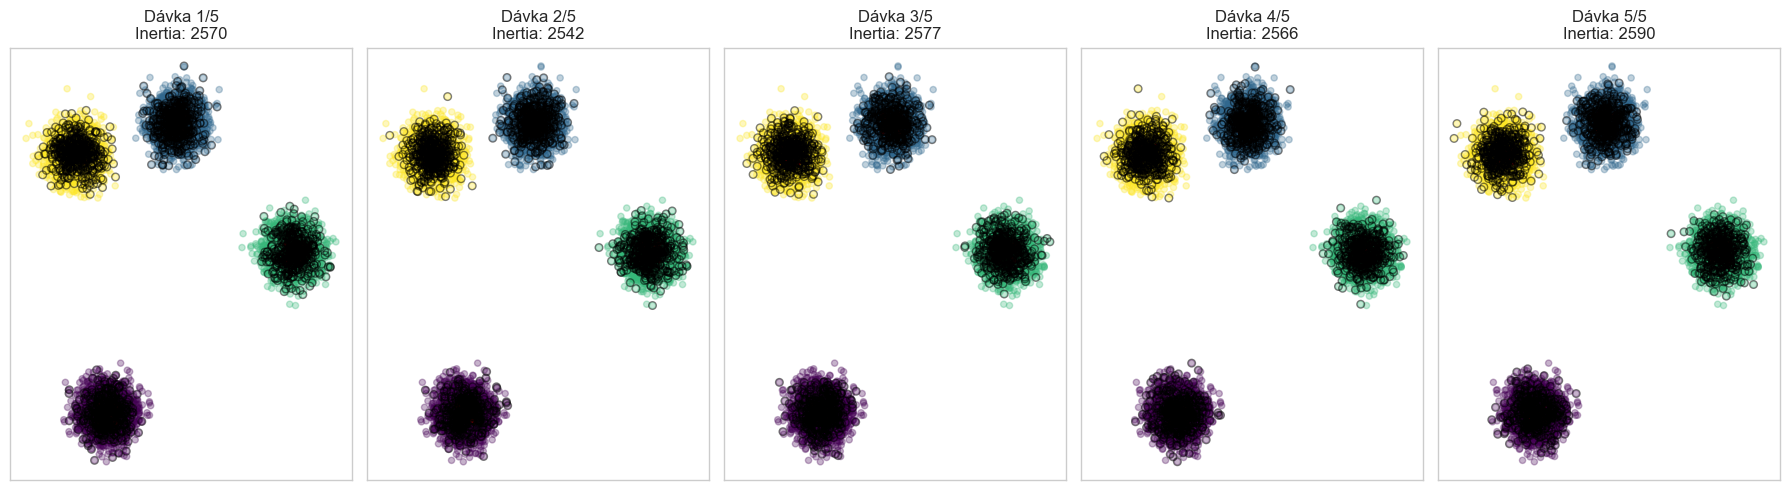

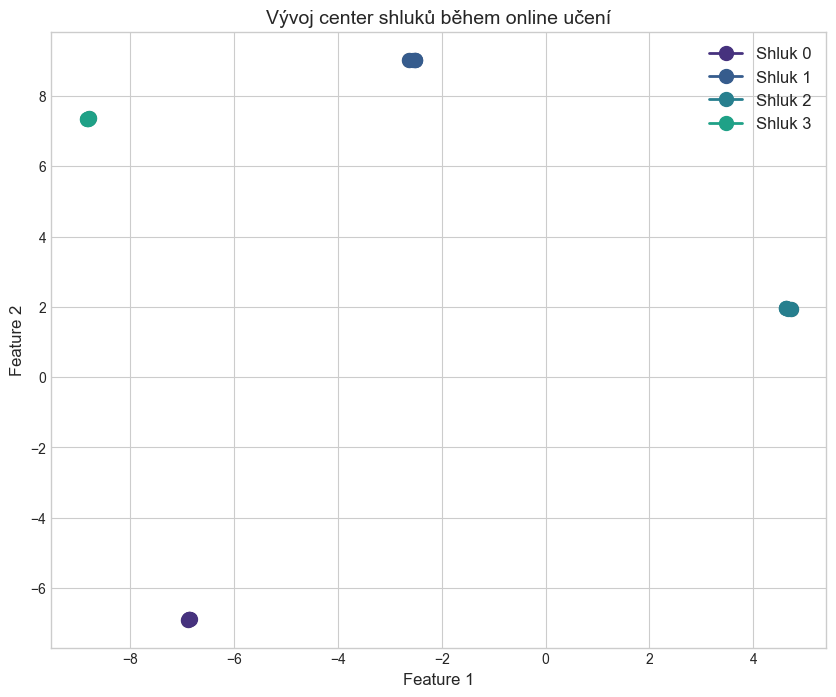

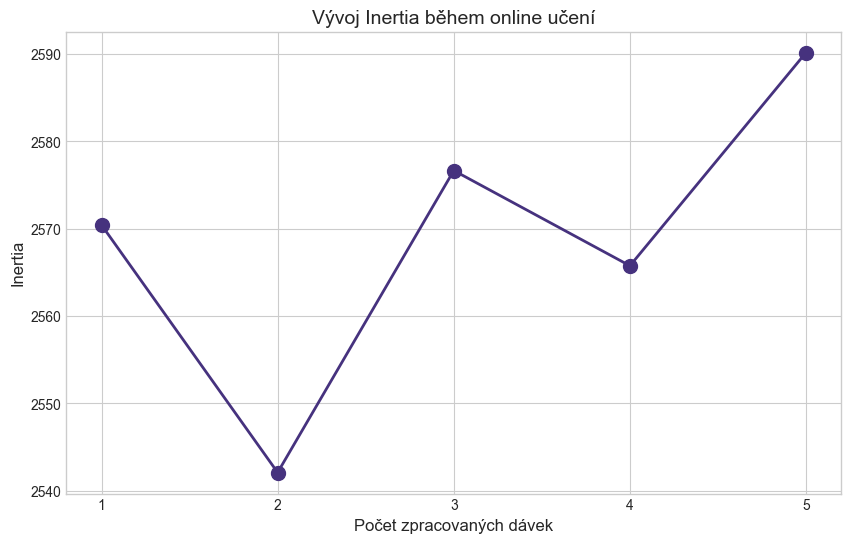

In [10]:
# Vytvoříme datovou sadu, kterou rozdělíme na několik dávek
n_samples_total = 10000
n_batches = 5
batch_size = n_samples_total // n_batches

# Generování dat
X_total, y_total = make_blobs(n_samples=n_samples_total, 
                             n_features=2,
                             centers=4,
                             cluster_std=0.8,
                             random_state=42)

# Inicializace MiniBatch KMeans
mbk_online = MiniBatchKMeans(n_clusters=4, batch_size=100, random_state=42)

# Sledujeme vývoj středů shluků v průběhu online učení
centers_history = []
inertia_history = []

# Vizualizace online učení
fig, axes = plt.subplots(1, n_batches, figsize=(18, 5))

for i in range(n_batches):
    # Získání dávky dat
    start_idx = i * batch_size
    end_idx = (i + 1) * batch_size
    X_batch = X_total[start_idx:end_idx]
    y_batch = y_total[start_idx:end_idx]
    
    # Částečné učení modelu na této dávce
    mbk_online.partial_fit(X_batch)
    
    # Uložení aktuálních středů a inertia
    centers_history.append(mbk_online.cluster_centers_.copy())
    inertia_history.append(mbk_online.inertia_)
    
    # Predikce shluků pro celou datovou sadu
    labels = mbk_online.predict(X_total)
    
    # Vykreslení aktuálního stavu
    axes[i].scatter(X_total[:, 0], X_total[:, 1], c=labels, cmap='viridis', alpha=0.3, s=20)
    axes[i].scatter(mbk_online.cluster_centers_[:, 0], mbk_online.cluster_centers_[:, 1], 
                   c='red', marker='x', s=200, linewidths=3)
    
    # Zvýraznění aktuální dávky
    axes[i].scatter(X_batch[:, 0], X_batch[:, 1], edgecolor='black', facecolor='none', s=30, alpha=0.5)
    
    axes[i].set_title(f"Dávka {i+1}/{n_batches}\nInertia: {mbk_online.inertia_:.0f}", fontsize=12)
    axes[i].set_xlim([X_total[:, 0].min() - 1, X_total[:, 0].max() + 1])
    axes[i].set_ylim([X_total[:, 1].min() - 1, X_total[:, 1].max() + 1])
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

# Vizualizace změn center shluků v průběhu času
plt.figure(figsize=(10, 8))

for cluster_idx in range(4):
    # Extrakce souřadnic center specifického shluku ze všech iterací
    center_x = [centers[cluster_idx][0] for centers in centers_history]
    center_y = [centers[cluster_idx][1] for centers in centers_history]
    
    plt.plot(center_x, center_y, 'o-', linewidth=2, markersize=10,
            label=f"Shluk {cluster_idx}")
    
    # Zobrazení počátečního a koncového bodu
    plt.scatter([center_x[0]], [center_y[0]], c='black', s=100, marker='o', alpha=0.5)
    plt.scatter([center_x[-1]], [center_y[-1]], c='red', s=100, marker='*')

plt.title('Vývoj center shluků během online učení', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

# Vizualizace změny inertia v průběhu času
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_batches + 1), inertia_history, 'o-', linewidth=2, markersize=10)
plt.title('Vývoj Inertia během online učení', fontsize=14)
plt.xlabel('Počet zpracovaných dávek', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(True)
plt.xticks(range(1, n_batches + 1))
plt.show()

## 9. Shrnutí a závěr

### Výhody MiniBatch KMeans:
- **Rychlost** - Výrazně rychlejší než standardní KMeans, zejména pro velké datové sady
- **Paměťová efektivita** - Pracuje pouze s malými dávkami dat v paměti
- **Online učení** - Schopnost postupně zpracovávat nová data bez nutnosti přetrénovat celý model
- **Škálovatelnost** - Dobře škáluje na velmi velké datové sady
- **Podobná kvalita** - Ve většině případů poskytuje výsledky srovnatelné s KMeans

### Nevýhody MiniBatch KMeans:
- **Nižší stabilita** - Výsledky mohou být o něco méně stabilní než u standardního KMeans
- **Mírně horší kvalita** - V některých případech může dávat o něco horší výsledky (vyšší inertia)
- **Citlivost na batch_size** - Výsledky mohou záviset na zvolené velikosti dávky
- **Stále citlivé na inicializaci** - Podobně jako KMeans závisí na počáteční inicializaci center

### Klíčové parametry:
- **n_clusters** - Počet shluků
- **batch_size** - Velikost mini-dávky (kompromis mezi rychlostí a kvalitou)
- **max_iter** - Maximální počet iterací
- **init** - Metoda inicializace center ('k-means++', 'random')
- **reassignment_ratio** - Určuje jak často jsou přiřazeny nové centrum pro každý shluk

### Kdy použít MiniBatch KMeans místo standardního KMeans:
1. Když pracujete s velkými datovými sadami (miliony vzorků)
2. Když je rychlost důležitější než absolutní přesnost
3. Při online učení, kdy data přichází v dávkách
4. Pro rychlé prototypování a průzkumné analýzy dat